## Scenario
A fast-food chain plans to add a new item to its menu. However, they are still undecided between three possible marketing campaigns for promoting the new product.  
In order to determine which promotion has the greatest effect on sales, the new item is introduced at locations in several randomly selected markets.  
A different promotion is used at each location, and the weekly sales of the new item are recorded for the first four weeks.

## Goal
The goal is to identify the most effective promotion in terms of average sales per location and to determine whether the effect is short-term or consistent over the four-week test period.

Based on this setup, the next step is to define the hypotheses.  
Since we want to find out whether the three promotions differ in their average sales performance, we first will do an ANOVA test.  
This test will tell us whether there is any significant difference at all across the three promotion groups.  

If the ANOVA test turns out to be significant, we can then compare the promotions pairwise via Tukey HSD test.  
This is needed because the ANOVA itself only tells us that a difference exists somewhere, but not yet between which specific promotions.  

## Hypotheses

### 1. ANOVA test

**H0:** There is no significant difference in mean sales across Promotion 1, Promotion 2, and Promotion 3.  

**H1:** At least one promotion group has a significantly different mean sales value compared to the others.  


### 2. Tukey HSD test

**Promotion 1 vs Promotion 2**  
**H0:** There is no significant difference in mean sales between Promotion 1 and Promotion 2.  
**H1:** There is a significant difference in mean sales between Promotion 1 and Promotion 2.  

**Promotion 1 vs Promotion 3**  
**H0:** There is no significant difference in mean sales between Promotion 1 and Promotion 3.  
**H1:** There is a significant difference in mean sales between Promotion 1 and Promotion 3.  

**Promotion 2 vs Promotion 3**  
**H0:** There is no significant difference in mean sales between Promotion 2 and Promotion 3.  
**H1:** There is a significant difference in mean sales between Promotion 2 and Promotion 3.  



## Quality and Balance Check

In [ ]:
# importing necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chisquare, chi2_contingency, f_oneway, kruskal
from scipy.stats import f_oneway, levene, kruskal
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [ ]:
url = '/Users/eliza.cekavice/Documents/AB/WA_Marketing-Campaign.csv'

df = pd.read_csv(url, encoding='utf-8')

df.head()

,MarketID,MarketSize,LocationID,AgeOfStore,Promotion,week,SalesInThousands
0,1,Medium,1,4,3,1,33.73
1,1,Medium,1,4,3,2,35.67
2,1,Medium,1,4,3,3,29.03
3,1,Medium,1,4,3,4,39.25
4,1,Medium,2,5,2,1,27.81


1. MarketID: unique identifier for market
2. MarketSize: size of market area by sales
3. LocationID: unique identifier for store location
4. AgeOfStore: age of store in years
5. Promotion: one of three promotions that were tested
6. week: one of four weeks when the promotions were run
7. SalesInThousands: sales amount for a specific LocationID, Promotion, and week

In [ ]:
df.shape

(548, 7)

In [ ]:
df.isnull().sum()

MarketID            0
MarketSize          0
LocationID          0
AgeOfStore          0
Promotion           0
week                0
SalesInThousands    0
dtype: int64

Let's check for duplicates

In [ ]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
543    False
544    False
545    False
546    False
547    False
Length: 548, dtype: bool

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 548 entries, 0 to 547
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   MarketID          548 non-null    int64  
 1   MarketSize        548 non-null    object 
 2   LocationID        548 non-null    int64  
 3   AgeOfStore        548 non-null    int64  
 4   Promotion         548 non-null    int64  
 5   week              548 non-null    int64  
 6   SalesInThousands  548 non-null    float64
dtypes: float64(1), int64(5), object(1)
memory usage: 30.1+ KB


Ok so, the dataset contains no null values, no duplicates and it has 7 columns with 548 rows.  
It seems that we have 6 numerical variables and 1 categorical variable.  
However, MarketID, LocationID, and Promotion are identifiers represented as numbers.  
So in reality, they should be treated as categories.  
Togehter with MarketSize I will transform them into the category type for easier handling.  

So in reality we have 3 numerical and 4 categorical variables.

In [ ]:
cols_cat_change = ['MarketSize', 'LocationID', 'MarketID', 'Promotion']

for col in cols_cat_change:
        df[col] = df[col].astype('category')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 548 entries, 0 to 547
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   MarketID          548 non-null    category
 1   MarketSize        548 non-null    category
 2   LocationID        548 non-null    category
 3   AgeOfStore        548 non-null    int64   
 4   Promotion         548 non-null    category
 5   week              548 non-null    int64   
 6   SalesInThousands  548 non-null    float64 
dtypes: category(4), float64(1), int64(2)
memory usage: 21.4 KB


Let's do a sample ratio check.  
Was every promotion done in every market size?  
Is the Location distribution equal.  
What's the distribution of small, medium and large markets in each promotion.

In [ ]:
df_locations = df[['LocationID', 'MarketSize', 'Promotion', 'AgeOfStore']].drop_duplicates()

df_locations

,LocationID,MarketSize,Promotion,AgeOfStore
0,1,Medium,3,4
4,2,Medium,2,5
8,3,Medium,1,12
12,4,Medium,2,1
16,5,Medium,2,10
...,...,...,...,...
528,916,Large,2,7
532,917,Large,3,14
536,918,Large,1,6
540,919,Large,1,2


In [ ]:
df_locations.groupby('MarketSize', observed=True)['LocationID'].count()

MarketSize
Large     42
Medium    80
Small     15
Name: LocationID, dtype: int64

In [ ]:
df_locations.groupby(['Promotion'], observed=True)['LocationID'].count()

Promotion
1    43
2    47
3    47
Name: LocationID, dtype: int64

In [ ]:
df_locations.groupby(['Promotion', 'MarketSize'], observed=True)['LocationID'].count().unstack(fill_value=0)

MarketSize,Large,Medium,Small
Promotion,,,
1,14,24,5
2,16,27,4
3,12,29,6


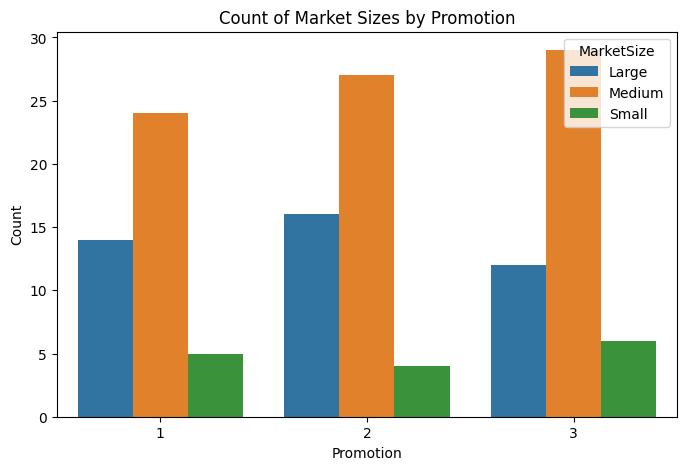

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df_locations, x='Promotion', hue='MarketSize')
plt.title('Count of Market Sizes by Promotion')
plt.xlabel('Promotion')
plt.ylabel('Count')
plt.show()

So far it looks like the campaigns were distributed fairly even.   
Which is good, because this means the results should be unbiased.    
If one promotion was run only in locations with naturally larger sales numbers and one only in locations with smaller sales, it would falsify the results.

Are age of a location and sales correlated?   
If yes, is the distribution of age within the promotions also evenly?

In [ ]:
df_locations.groupby('Promotion', observed=True)['AgeOfStore'].describe()

,count,mean,std,min,25%,50%,75%,max
Promotion,,,,,,,,
1,43.0,8.279070,6.695150,1.0,3.0,6.0,12.0,27.0
2,47.0,7.978723,6.651216,1.0,3.0,7.0,10.0,28.0
3,47.0,9.234043,6.705652,1.0,5.0,8.0,11.5,24.0


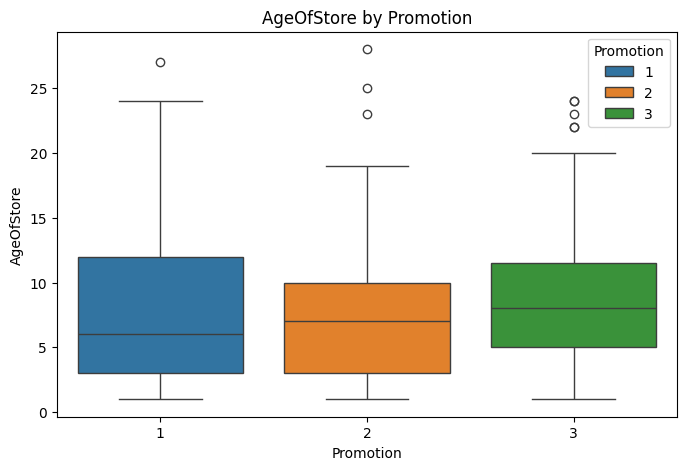

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_locations, x='Promotion', y='AgeOfStore', hue='Promotion')
plt.title('AgeOfStore by Promotion')
plt.show()

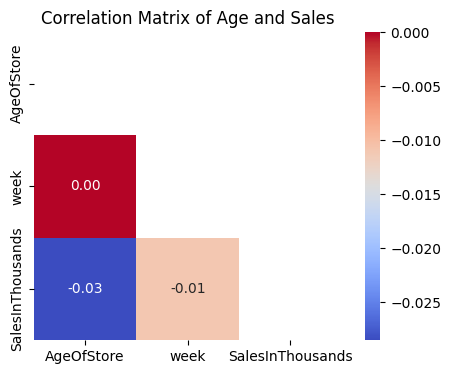

In [ ]:
numerical_features = df.select_dtypes(include=[np.number]).columns

correlation_matrix = df[numerical_features].corr()

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

plt.figure(figsize=(6, 4))
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', cbar=True, square=True)
plt.title('Correlation Matrix of Age and Sales')
plt.show()

The descriptive statistics and the boxplot do not suggest that one promotion was assigned mainly to very young or very old stores only.  

Though, Age of store does not seem to be meaningfully correlated with sales.  
The correlation between Age and weekly avgerage sales per location is around -0.03, which is very close to zero.  
So based on this, there is no indication that older or younger stores generate higher or lower sales.  

## Hypothesis test SRM and Distribution:
1. Do we have an equal ratio in each promotion of locations?
2. Is the distribution of market sizes in each promotion identical?

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import chisquare, chi2_contingency, f_oneway, kruskal

In [ ]:
observed_counts = df_locations['Promotion'].value_counts().sort_index()
observed_counts

Promotion
1    43
2    47
3    47
Name: count, dtype: int64

In [ ]:
total_n = observed_counts.sum()
expected_counts = np.repeat(total_n / len(observed_counts), len(observed_counts))

chi2_stat, p_value = chisquare(f_obs=observed_counts, f_exp=expected_counts)

print("Observed counts:")
print(observed_counts)
print("\nExpected counts:")
print(expected_counts)
print(f"\nChi-square statistic: {chi2_stat:.4f}")
print(f"P-value: {p_value:.6f}")

Observed counts:
Promotion
1    43
2    47
3    47
Name: count, dtype: int64

Expected counts:
[45.66666667 45.66666667 45.66666667]

Chi-square statistic: 0.2336
P-value: 0.889774


Alpha = 0.05

The p-value of is very high, meaning that under the null hypothesis of no sample ratio mismatch, the probality to observe such difference is 88.98%.  
Hence, we can't reject H0, meaning there is no evidence of a sample ratio mismatch between the groups.

In [ ]:
contingency_market = pd.crosstab(df_locations['Promotion'], df_locations['MarketSize'])
contingency_market

MarketSize,Large,Medium,Small
Promotion,,,
1,14,24,5
2,16,27,4
3,12,29,6


In [ ]:
chi2_stat, p_value, dof, expected = chi2_contingency(contingency_market)

print("Contingency table:")
print(contingency_market)
print(f"\nChi-square statistic: {chi2_stat:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"P-value: {p_value:.6f}")

Contingency table:
MarketSize  Large  Medium  Small
Promotion                       
1              14      24      5
2              16      27      4
3              12      29      6

Chi-square statistic: 1.1885
Degrees of freedom: 4
P-value: 0.879993


Again we can't reject the null hypothesis.  
The p-value is above 0.05.
So the distribution of Marketsize across the promotions doesn't differ significantly. 

## Visualisations of the weekly average per location

Before conducting the ANOVA and Tukey test, I first wanted to look at the results of each promotion visually.

Additionally, in order to decide which promotion is the winner, I would evaluate two metrics.

1. The weekly average sales per location across all 4 weeks
2. and then I would also compare the weekly average sales per location for weeks 1–2 between the promotions as well as for weeks 3–4.

Because it would not only show which promotion performs best overall, but also whether the effect is stable over time or only short lived.

A promotion could look strong when averaging over all 4 weeks, but this average might hide that the effect was only high in the beginning and then dropped afterwards.
By splitting the analysis into weeks 1–2 and weeks 3–4, I can check whether the promotion effect remains consistent or whether it weakens over time.

In [ ]:
df_avg_weeks = (
    df.groupby(['MarketSize', 'LocationID', 'AgeOfStore', 'Promotion'], observed=True, as_index=False)
      .agg(
          avg_sales_4w   = ('SalesInThousands', 'mean'),
          avg_sales_wk_1_2 = ('SalesInThousands', lambda x: x[df.loc[x.index, 'week'].isin([1, 2])].mean()),
          avg_sales_wk_3_4 = ('SalesInThousands', lambda x: x[df.loc[x.index, 'week'].isin([3, 4])].mean())
      )
)

df_avg_weeks.head()

,MarketSize,LocationID,AgeOfStore,Promotion,avg_sales_4w,avg_sales_wk_1_2,avg_sales_wk_3_4
0,Large,201,4,3,81.3075,84.350,78.265
1,Large,202,8,1,87.4150,86.970,87.860
2,Large,203,12,3,83.3400,84.065,82.615
3,Large,204,1,2,83.1575,84.610,81.705
4,Large,205,19,3,87.0675,86.660,87.475


In [ ]:
df_avg_weeks.groupby('Promotion', observed=True)[['avg_sales_4w','avg_sales_wk_1_2', 'avg_sales_wk_3_4']].mean().round(2)

,avg_sales_4w,avg_sales_wk_1_2,avg_sales_wk_3_4
Promotion,,,
1,58.10,57.59,58.61
2,47.33,47.66,47.00
3,55.36,55.86,54.87


At first glance, Promotion 2 looks like the weakest one out of the three across all metrics.  
It has the lowest average sales per location over all 4 weeks and also stays the lowest when looking at weeks 1–2 and weeks 3–4 separately.  

What's more interesting is the comparison between Promotion 1 and Promotion 3.  
Here, Promotion 1 looks slightly stronger overall, as it generated around 58.10 average sales per location across all 4 weeks, compared to 55.36 for Promotion 3.  
Additionally, Promotion 1 even shows a small increase from weeks 1–2 to weeks 3–4, while Promotion 3 shows a slight decrease over time.  

## Statistical tests

Before conducting the ANOVA test, I am also going to perform a Levene test in order to check whether the variance of the three samples can be treated as equal.  
As this is a requirement for this test. 

In [ ]:
promo_1 = df_avg_weeks.loc[df_avg_weeks['Promotion'] == 1, 'avg_sales_4w']
promo_2 = df_avg_weeks.loc[df_avg_weeks['Promotion'] == 2, 'avg_sales_4w']
promo_3 = df_avg_weeks.loc[df_avg_weeks['Promotion'] == 3, 'avg_sales_4w']

In [ ]:
levene_stat, levene_p = levene(promo_1, promo_2, promo_3)

print(f"Levene statistic: {levene_stat:.4f}")
print(f"Levene p-value: {levene_p:.6f}")

Levene statistic: 0.4682
Levene p-value: 0.627173


Nice, with an alpha of 0.05 and a p-value bigger than that, our requirement of an equalvariance between the groups is met.

### ANOVA TEST

With alpha = 0.05

In [ ]:
anova_stat, anova_p = f_oneway(promo_1, promo_2, promo_3)

print(f"ANOVA F-statistic: {anova_stat:.4f}")
print(f"ANOVA p-value: {anova_p:.6f}")

ANOVA F-statistic: 5.8458
ANOVA p-value: 0.003681


Based on the results, there is only a small probality that under the null hypothesis we would observe no difference in average sales between the promotions.  
Which means that at least one promotion differs significantly in average sales.

In [ ]:
promo_1_wk12 = df_avg_weeks.loc[df_avg_weeks['Promotion'] == 1, 'avg_sales_wk_1_2']
promo_2_wk12 = df_avg_weeks.loc[df_avg_weeks['Promotion'] == 2, 'avg_sales_wk_1_2']
promo_3_wk12 = df_avg_weeks.loc[df_avg_weeks['Promotion'] == 3, 'avg_sales_wk_1_2']

anova_stat_wk12, anova_p_wk12 = f_oneway(promo_1_wk12, promo_2_wk12, promo_3_wk12)

print(f"Week 1-2 ANOVA F-statistic: {anova_stat_wk12:.4f}")
print(f"Week 1-2 ANOVA p-value: {anova_p_wk12:.6f}")

Week 1-2 ANOVA F-statistic: 5.2827
Week 1-2 ANOVA p-value: 0.006191


In [ ]:
promo_1_wk34 = df_avg_weeks.loc[df_avg_weeks['Promotion'] == 1, 'avg_sales_wk_3_4']
promo_2_wk34 = df_avg_weeks.loc[df_avg_weeks['Promotion'] == 2, 'avg_sales_wk_3_4']
promo_3_wk34 = df_avg_weeks.loc[df_avg_weeks['Promotion'] == 3, 'avg_sales_wk_3_4']

anova_stat_wk34, anova_p_wk34 = f_oneway(promo_1_wk34, promo_2_wk34, promo_3_wk34)

print(f"Week 3-4 ANOVA F-statistic: {anova_stat_wk34:.4f}")
print(f"Week 3-4 ANOVA p-value: {anova_p_wk34:.6f}")

Week 3-4 ANOVA F-statistic: 6.2752
Week 3-4 ANOVA p-value: 0.002482


The same applies to the average sales for the first two weeks (1-2) and the first two last weeks (3-4).  
Meaning that at least one promotion differs in average sales for weeks 1-2 and weeks 3-4.

## TUKEY HSD TEST

With alpha = 0.05

In [ ]:
tukey_primary = pairwise_tukeyhsd(endog=df_avg_weeks['avg_sales_4w'],groups=df_avg_weeks['Promotion'],alpha=0.05)

print(tukey_primary)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
     1      2 -10.7696  0.004 -18.5951  -2.944   True
     1      3  -2.7345 0.6862 -10.5601   5.091  False
     2      3   8.0351 0.0371   0.3854 15.6847   True
-----------------------------------------------------


In [ ]:
tukey_wk12 = pairwise_tukeyhsd(endog=df_avg_weeks['avg_sales_wk_1_2'],groups=df_avg_weeks['Promotion'],alpha=0.05)

print(tukey_wk12)

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     1      2  -9.9306 0.0087 -17.753 -2.1082   True
     1      3  -1.7243 0.8605 -9.5467  6.0981  False
     2      3   8.2063 0.0323  0.5597 15.8529   True
----------------------------------------------------


In [ ]:
tukey_wk34 = pairwise_tukeyhsd(endog=df_avg_weeks['avg_sales_wk_3_4'],groups=df_avg_weeks['Promotion'],alpha=0.05)

print(tukey_wk34)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
     1      2 -11.6086 0.0022 -19.5847 -3.6325   True
     1      3  -3.7448 0.5079 -11.7209  4.2313  False
     2      3   7.8638 0.0476    0.067 15.6607   True
-----------------------------------------------------


For the 4-week average sales per location, Promotion 1 performs significantly better than Promotion 2, and Promotion 3 also performs significantly better than Promotion 2.
However, there is no significant difference between Promotion 1 and Promotion 3.

The same pattern can be seen when looking at weeks 1–2 and weeks 3-4, where Promotions 2 is the weakest and the difference between 1 and 3 is not significant.  

This means that Promotion 2 can clearly be ruled out, but between Promotion 1 and Promotion 3 there is no statistically significant winner based on these tests.  

Hence, I would let the test run for either 1-2 weeks more, which would provide more data and increase the power, or just choose Promotion 1 based on the descriptive results,  
since it looks slightly stronger in and also shows a small positive trend over time, while Promotion 3 declines slightly.